In [1]:
from kaggle_environments import make

env = make('connectx')

rows = env.configuration.rows
columns = env.configuration.columns
inarow = env.configuration.inarow

assert rows == 6
assert columns == 7
assert inarow == 4

In [2]:
import torch
import numpy as np
import os

def seed_everything(seed):
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

seed_everything(42)

In [3]:
from types import SimpleNamespace
from my_dqn import My_DQN

device = 'cuda'
env_config = env.configuration
my_config = SimpleNamespace(
    h=128
)

Q_func = My_DQN(env_config, my_config, device)

In [4]:
Y = Q_func(torch.ones(5, 42, device=device))
print(Y)

tensor([[-0.0084, -0.0341, -0.0550, -0.0520, -0.0039,  0.0553, -0.0062],
        [-0.0084, -0.0341, -0.0550, -0.0520, -0.0039,  0.0553, -0.0062],
        [-0.0084, -0.0341, -0.0550, -0.0520, -0.0039,  0.0553, -0.0062],
        [-0.0084, -0.0341, -0.0550, -0.0520, -0.0039,  0.0553, -0.0062],
        [-0.0084, -0.0341, -0.0550, -0.0520, -0.0039,  0.0553, -0.0062]],
       device='cuda:0', grad_fn=<AddmmBackward0>)


---


Initialize replay memory $D$ to capacity $N$

Initialize action-value function $Q$ with random weights $\theta$

Initialize target action-value function $\hat{Q}$ with weights $\theta^- = \theta$

**For** episode $= 1, M$ **do**

$\quad$ Initialize sequence $s_1 = \{x_1\}$ and preprocessed sequence $\phi_1 = \phi(s_1)$

$\quad$ **For** $t = 1, T$ **do**

$\qquad$ With probability $\varepsilon$ select a random action $a_t$

$\qquad$ otherwise select $a_t = \text{argmax}_a Q(\phi(s_t), a; \theta)$

$\qquad$ Execute action $a_t$ in emulator and observe reward $r_t$ and image $x_{t+1}$

$\qquad$ Set $s_{t+1} = s_t, a_t, x_{t+1}$ and preprocess $\phi_{t+1} = \phi(s_{t+1})$

$\qquad$ Store transition $(\phi_t, a_t, r_t, \phi_{t+1})$ in $D$

$\qquad$ Sample random minibatch of transitions $(\phi_j, a_j, r_j, \phi_{j+1})$ from $D$

$\qquad$ Set $y_j = \begin{cases} r_j & \text{if episode terminates at step } j+1 \\ r_j + \gamma \max_{a'} \hat{Q}(\phi_{j+1}, a'; \theta^-) & \text{otherwise} \end{cases}$

$\qquad$ Perform a gradient descent step on $\left(y_j - Q(\phi_j, a_j; \theta)\right)^2$ with respect to the network parameters $\theta$

$\qquad$ Every $C$ steps reset $\hat{Q} = Q$

$\quad$ **End For**

**End For**

In [5]:
from op_agents.jekiwantaufik import jekiwantaufik


reward_for_inarow = torch.arange(inarow + 1, device=device) / inarow
reward_for_inarow[:2] = 0

train_config = SimpleNamespace(
    batch_size = 128,
    total_steps = 10000,
    epsilon = 0.1, # ???
    op_agents = ['random', 'negamax', jekiwantaufik],
    move_target_every = 50,

    validate_every = 1000,
    num_episodes = 100,
    val_op_agent = 'negamax',

    reward_for_None = -5,
    reward_for_inarow = reward_for_inarow,
    state_reward_coeff = 0.01
)

In [6]:
from torch.optim import AdamW
from torch.optim.lr_scheduler import LinearLR

optimizer = AdamW(Q_func.parameters())
scheduler = LinearLR(
    optimizer, 
    start_factor=0.1, 
    end_factor=1, 
    total_iters=(train_config.total_steps - 2 * train_config.batch_size) / 2)

In [7]:
from train import train

logs = train(Q_func, optimizer, scheduler, my_config, env_config, train_config, device=device)

| step: 100 |
| step: 200 |
| step: 300 | loss: 1.4333 |
| step: 400 | loss: 1.7413 |
| step: 500 | loss: 0.9120 |
| step: 600 | loss: 0.6647 |
| step: 700 | loss: 0.3332 |
| step: 800 | loss: 0.1713 |
| step: 900 | loss: 0.1822 |
| step: 1000 | loss: 0.2643 |
| step: 1000 | val_reward: -1.0000 |
| step: 1100 | loss: 0.1844 |
| step: 1200 | loss: 0.1897 |
| step: 1300 | loss: 0.1151 |
| step: 1400 | loss: 0.0987 |
| step: 1500 | loss: 0.1209 |
| step: 1600 | loss: 0.1095 |
| step: 1700 | loss: 0.1412 |
| step: 1800 | loss: 0.4165 |
| step: 1900 | loss: 0.2432 |
| step: 2000 | loss: 0.1958 |
| step: 2000 | val_reward: -0.9700 |
| step: 2100 | loss: 0.1955 |
| step: 2200 | loss: 0.1770 |
| step: 2300 | loss: 0.1608 |
| step: 2400 | loss: 0.1837 |
| step: 2500 | loss: 0.1840 |
| step: 2600 | loss: 0.1749 |
| step: 2700 | loss: 0.2882 |
| step: 2800 | loss: 0.1691 |
| step: 2900 | loss: 0.2008 |
| step: 3000 | loss: 0.2509 |
| step: 3000 | val_reward: -0.9000 |
| step: 3100 | loss: 0.2487 

In [12]:
# train_config.total_steps = 10000
logs = train(Q_func, optimizer, scheduler, my_config, env_config, train_config, device=device)

| step: 100 |
| step: 200 |
| step: 300 | loss: 0.1128 |
| step: 400 | loss: 0.1358 |
| step: 500 | loss: 0.1235 |
| step: 600 | loss: 0.2089 |
| step: 700 | loss: 0.0602 |
| step: 800 | loss: 0.0592 |
| step: 900 | loss: 0.0526 |
| step: 1000 | loss: 0.0706 |
| step: 1000 | val_reward: -0.8400 |
| step: 1100 | loss: 0.0945 |
| step: 1200 | loss: 0.1439 |
| step: 1300 | loss: 0.1288 |
| step: 1400 | loss: 0.1604 |
| step: 1500 | loss: 0.5359 |
| step: 1600 | loss: 1.1663 |
| step: 1700 | loss: 1.0727 |
| step: 1800 | loss: 0.5340 |
| step: 1900 | loss: 1.1525 |
| step: 2000 | loss: 1.2761 |
| step: 2000 | val_reward: -0.8500 |
| step: 2100 | loss: 1.3955 |
| step: 2200 | loss: 4.2068 |
| step: 2300 | loss: 18.4713 |
| step: 2400 | loss: 4.9415 |
| step: 2500 | loss: 1.7205 |
| step: 2600 | loss: 4.2857 |
| step: 2700 | loss: 3.6963 |
| step: 2800 | loss: 9.1254 |
| step: 2900 | loss: 6.0923 |
| step: 3000 | loss: 3.0726 |
| step: 3000 | val_reward: -0.8800 |
| step: 3100 | loss: 6.1399

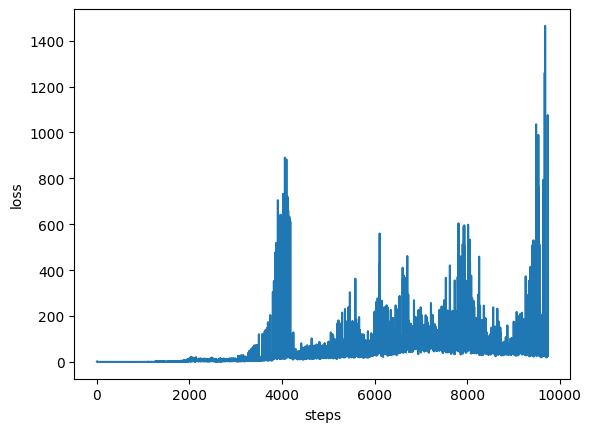

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.lineplot(x=range(len(logs['loss'])), y=logs['loss'])
plt.xlabel('steps')
plt.ylabel('loss')
plt.show()

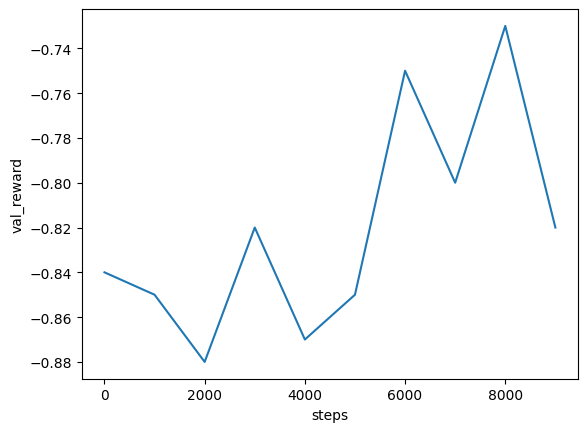

In [14]:
sns.lineplot(
    x=range(1, train_config.total_steps + 1, train_config.validate_every), 
    y=logs['val_reward']
)
plt.xlabel('steps')
plt.ylabel('val_reward')
plt.show()

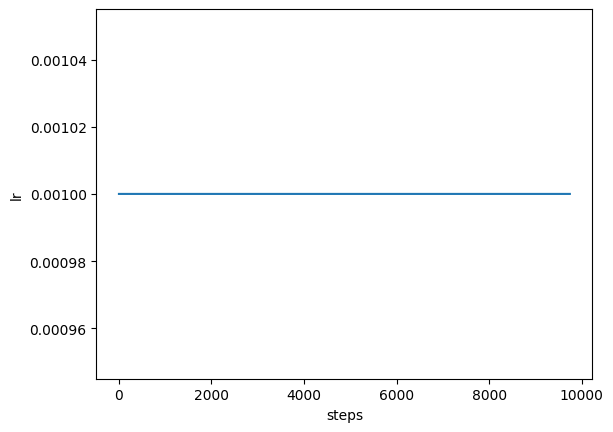

In [15]:
sns.lineplot(x=range(len(logs['lr'])), y=logs['lr'])
plt.xlabel('steps')
plt.ylabel('lr')
plt.show()

In [32]:
# with open("weights.py", "w") as f:
#     f.write("import torch\n")
#     f.write('from collections import OrderedDict\n\n\n')
#     f.write("state_dict = OrderedDict({\n")

#     for name, tensor in state_dict.items():
#         f.write(f"\t{name!r}: torch.tensor(")
#         f.write(repr(tensor.cpu().tolist()))
#         f.write(f", dtype=torch.{str(tensor.dtype).split('.')[-1]}),\n")

#     f.write("})\n")

In [38]:
import inspect
from my_dqn import My_DQN
from types import SimpleNamespace
from utilities import process_state


def my_agent(obs, env_config):
    assert env_config.rows == 6
    assert env_config.columns == 7
    assert env_config.inarow == 4

    my_config = SimpleNamespace(
        h=128
    )

    Q_func = My_DQN(env_config, my_config)
    Q_func.load_state_dict(state_dict)

    moves = Q_func(process_state(obs)[None,:])[0]
    mask_board = torch.tensor(obs.board[:env_config.columns], dtype=bool)

    action = torch.masked_fill(moves, mask_board, -float('inf')).argmax().item()
    print('action:', action)
    return action

def make_submission(Q_func):
    state_dict = Q_func.state_dict()

    with open('submission.py', 'w') as f:
        f.write('import torch\n')
        f.write('from types import SimpleNamespace\n')
        f.write('from collections import OrderedDict\n')
        f.write('\n\n')

        f.write('state_dict = OrderedDict({\n')
        for name, tensor in state_dict.items():
            f.write(f'\t{name!r}: torch.tensor(')
            f.write(repr(tensor.cpu().tolist()))
            f.write(f', dtype=torch.{str(tensor.dtype).split('.')[-1]}),\n')
        f.write('})\n\n\n')

        f.write(f'{inspect.getsource(My_DQN)}\n\n')
        f.write(f'{inspect.getsource(process_state)}\n\n')
        f.write(f'{inspect.getsource(my_agent)}\n\n')

In [40]:
make_submission(Q_func)

In [45]:
from validation import validate


train_config.val_op_agent = 'random'
print(validate(Q_func, device=device))

0.27
